In [3]:
import pandas as pd
import seaborn as sns

In [6]:
df = pd.read_csv("Loan_dataset.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN
977,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN
978,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN
979,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN


In [ ]:
# Basic info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    str    
 1   Gender             957 non-null    str    
 2   Married            978 non-null    str    
 3   Dependents         956 non-null    str    
 4   Education          981 non-null    str    
 5   Self_Employed      926 non-null    str    
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 99.8 KB


In [8]:
# Shape of the dataset
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset shape: (981, 13)
Rows: 981, Columns: 13


In [9]:
# Statistical summary
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [10]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values in each column:
Loan_ID                0
Gender                24
Married                3
Dependents            25
Education              0
Self_Employed         55
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount            27
Loan_Amount_Term      20
Credit_History        79
Property_Area          0
Loan_Status          367
dtype: int64

Total missing values: 600


In [11]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [12]:
# Data types of each column
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

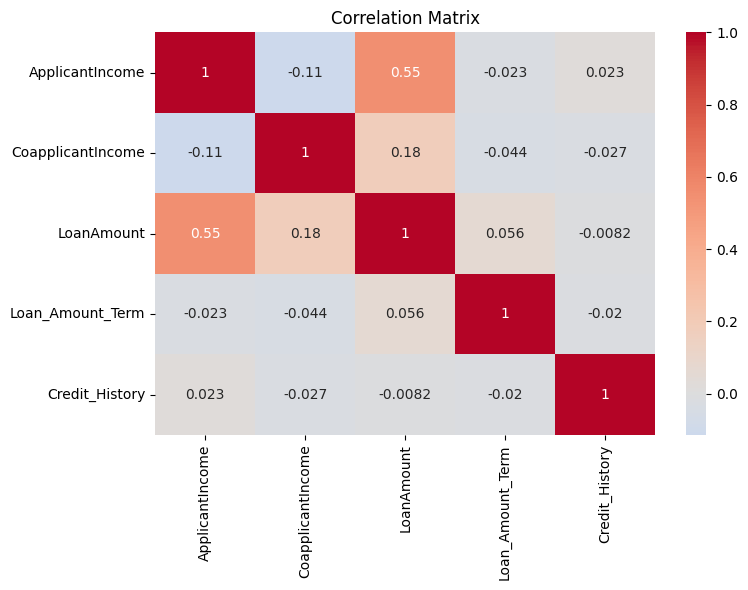

In [33]:
# Correlation matrix for numerical columns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

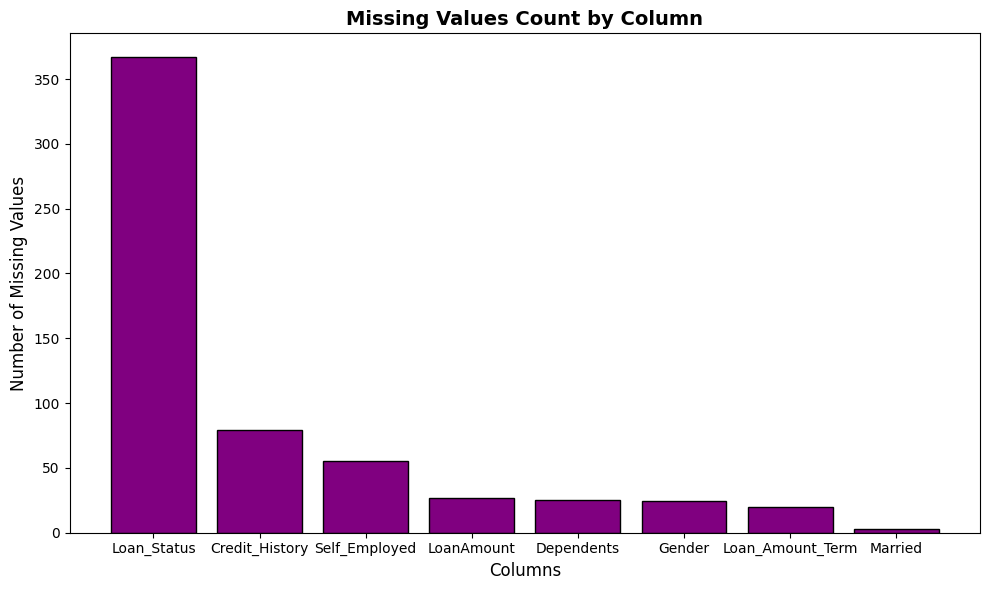

In [27]:
# Visualize missing values count
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    plt.figure(figsize=(10, 6))
    plt.bar(missing_values.index, missing_values.values, color='purple', edgecolor='black')
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.title('Missing Values Count by Column', fontsize=14, fontweight='bold')
    # plt.xticks(rotation=45, ha='right')
    # plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

C:\Users\DWIVEDT\AppData\Local\Temp\ipykernel_27228\589028723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values, palette='coolwarm')


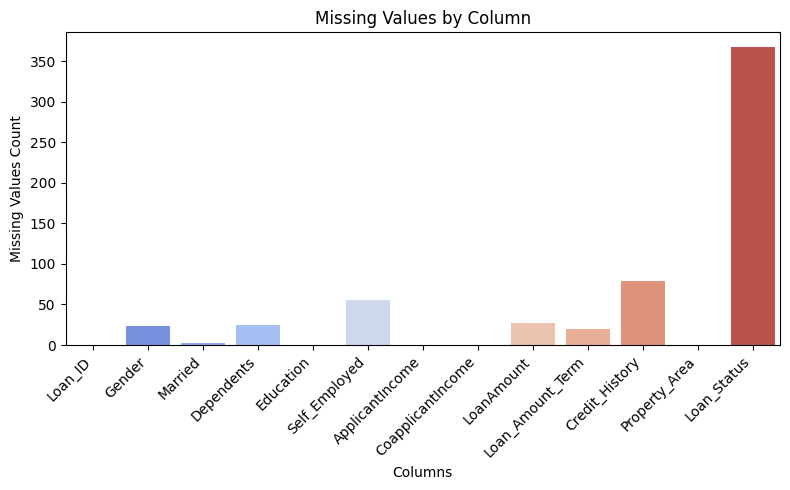

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values, palette='coolwarm')
plt.xlabel('Columns')
plt.ylabel('Missing Values Count')
plt.title('Missing Values by Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

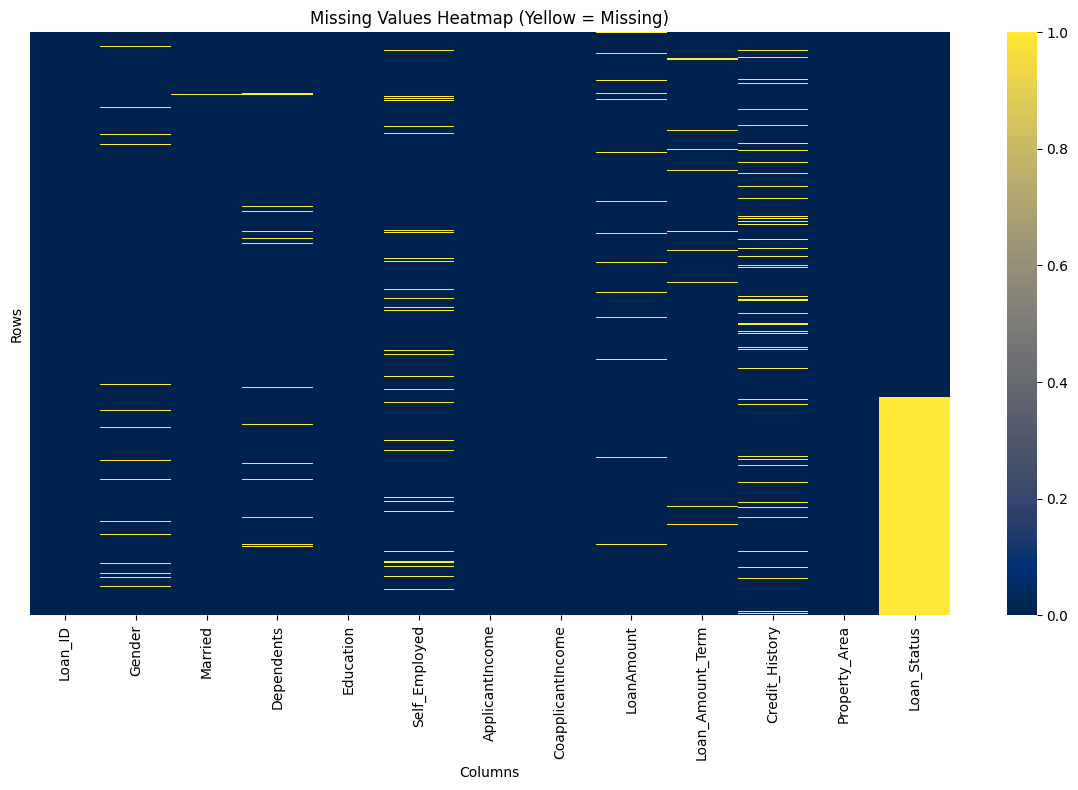

In [39]:
# Heatmap showing missing values in the dataset
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=True, cmap='cividis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

<Axes: xlabel='Loan_Status'>

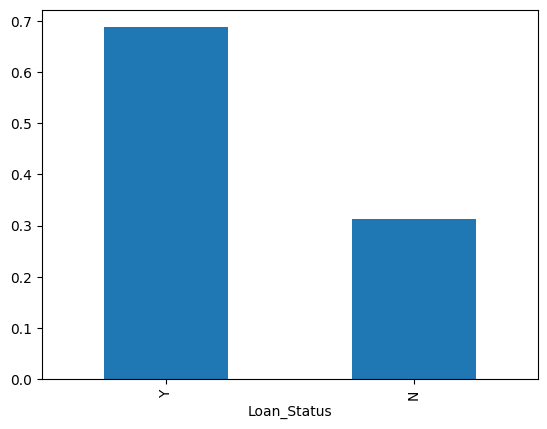

In [44]:
#Target variable analysis
df['Loan_Status'].value_counts()
df['Loan_Status'].value_counts(normalize=True)*100
df['Loan_Status'].value_counts(normalize=True).plot.bar()


<Axes: >

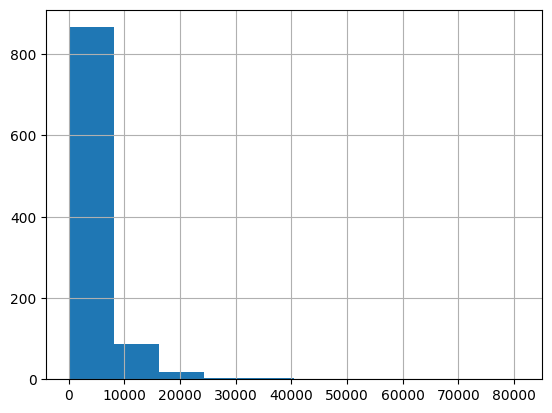

In [45]:
df['ApplicantIncome'].hist()

<Axes: >

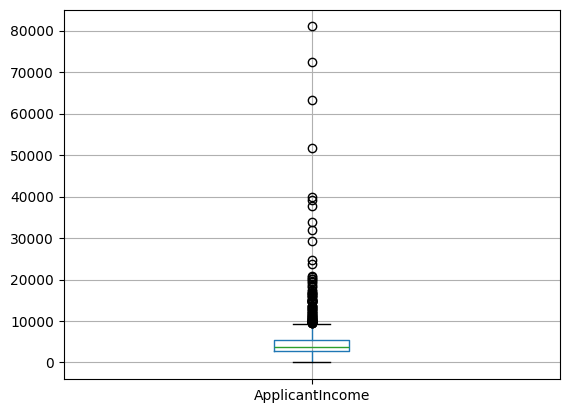

In [46]:
df.boxplot(column="ApplicantIncome")

<Axes: >

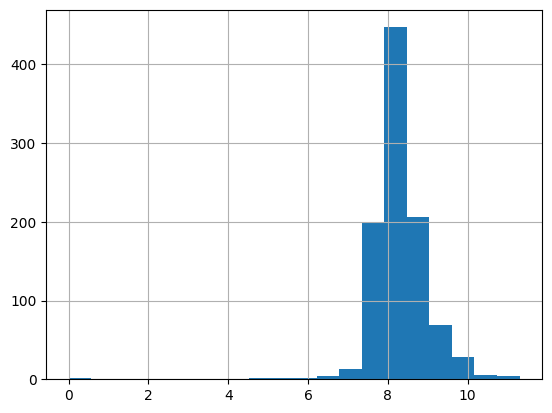

In [50]:
import numpy as np
#Income is right-skewed --> log transform needed
df["ApplicantIncome_log"] = np.log(df['ApplicantIncome']+1)
df['ApplicantIncome_log'].hist(bins=20)

In [52]:
from sklearn.linear_model import LogisticRegression
import seaborn as sb
pd.crosstab(df['Married'],df['Loan_Status'],normalize="index")*100

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.391960,71.608040


In [53]:
pd.crosstab(df['Dependents'],df['Loan_Status'],normalize="index")*100

Loan_Status,N,Y
Dependents,,
0,31.014493,68.985507
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


In [60]:
df['Dependents'].fillna('0', inplace=True)

C:\Users\DWIVEDT\AppData\Local\Temp\ipykernel_27228\4287590747.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Dependents'].fillna('0', inplace=True)


0       0
1       1
2       0
3       0
4       0
       ..
976    3+
977     0
978     0
979     0
980     0
Name: Dependents, Length: 981, dtype: str

In [59]:
df.isnull().sum()

Loan_ID                    0
Gender                    24
Married                    3
Dependents                25
Education                  0
Self_Employed             55
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                27
Loan_Amount_Term          20
Credit_History            79
Property_Area              0
Loan_Status              367
ApplicationIncome_log      0
ApplicantIncome_log        0
dtype: int64

In [61]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicationIncome_log,ApplicantIncome_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,8.674197,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,8.430327,8.430327
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,8.006701,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,7.857094,7.857094
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,8.699681,8.699681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
976,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777.0,113.0,360.0,1.0,Urban,NaN,8.296547,8.296547
977,LP002975,Male,Yes,0,Graduate,No,4158,709.0,115.0,360.0,1.0,Urban,NaN,8.333030,8.333030
978,LP002980,Male,No,0,Graduate,No,3250,1993.0,126.0,360.0,NaN,Semiurban,NaN,8.086718,8.086718
979,LP002986,Male,Yes,0,Graduate,No,5000,2393.0,158.0,360.0,1.0,Rural,NaN,8.517393,8.517393


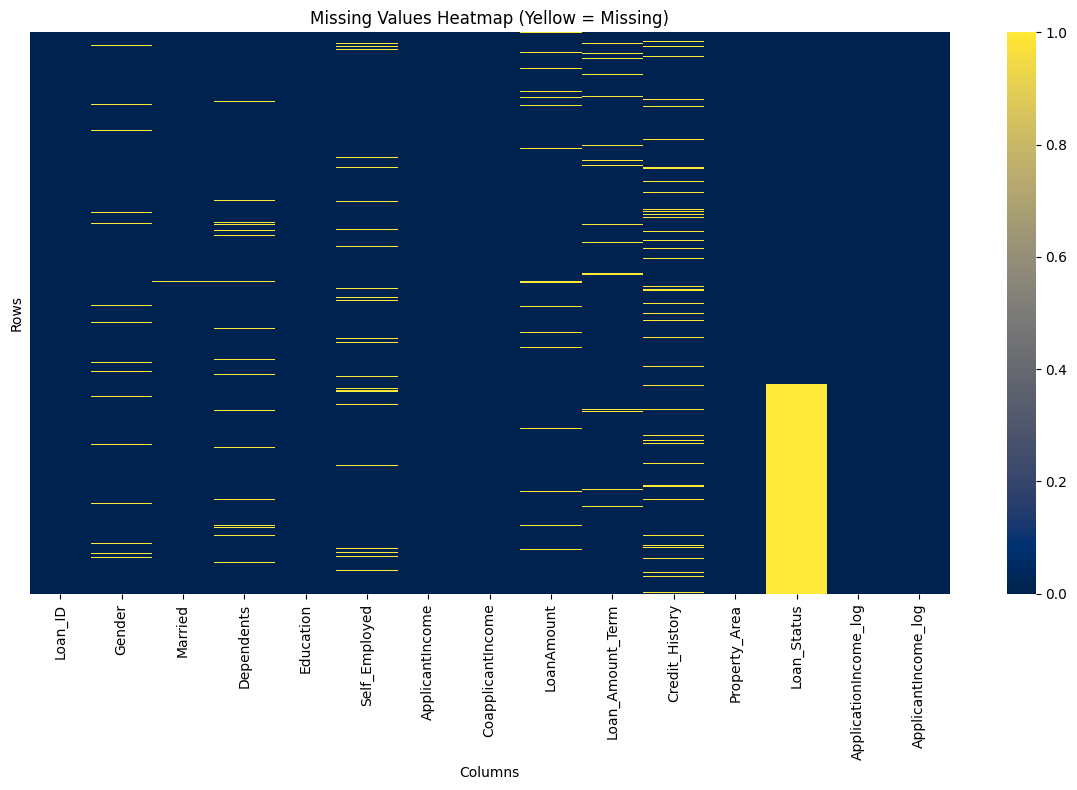

In [62]:
# Heatmap showing missing values in the dataset
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=True, cmap='cividis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

In [63]:
# Check current missing values in Dependents
print(f"Missing values before: {df['Dependents'].isnull().sum()}")

# Fill missing values with 0
df['Dependents'].fillna('0', inplace=True)

# Verify after filling
print(f"Missing values after: {df['Dependents'].isnull().sum()}")
print(f"\nDependents value counts:")
print(df['Dependents'].value_counts())

Missing values before: 25
Missing values after: 25

Dependents value counts:
Dependents
0     545
1     160
2     160
3+     91
Name: count, dtype: int64


C:\Users\DWIVEDT\AppData\Local\Temp\ipykernel_27228\1036627316.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Dependents'].fillna('0', inplace=True)


In [64]:
 df["Dependents"].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

In [65]:
# Replace NaN with '0' in Dependents column
df['Dependents'] = df['Dependents'].fillna('0')

# Verify the change
print("Unique values after replacement:")
print(df['Dependents'].unique())
print(f"\nMissing values: {df['Dependents'].isnull().sum()}")

Unique values after replacement:
<StringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str

Missing values: 0


In [66]:
df["Dependents"].isnull().sum()

np.int64(0)

In [67]:
# Replace '3+' with '3' in Dependents column
df['Dependents'] = df['Dependents'].replace('3+', '3')

# Verify the change
print("Unique values after replacement:")
print(df['Dependents'].unique())
print(f"\nValue counts:")
print(df['Dependents'].value_counts())

Unique values after replacement:
<StringArray>
['0', '1', '2', '3']
Length: 4, dtype: str

Value counts:
Dependents
0    570
1    160
2    160
3     91
Name: count, dtype: int64


In [69]:
df["Marrired"] = df["Married"].map({"No": 0, "Yes": 1})

df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

df["Education"] = df["Education"].map({"Not Graduate": 0, "Graduate": 1})

In [72]:
df["Gender"].isnull().sum()

np.int64(24)

In [73]:
# Features (all columns except target)
print(df["Married"].unique())
df["Married"]=df["Married"].fillna(df["Married"].mode())
df["Married"] = df["Married"].map({"No": 0, "Yes": 1})
print(df["Married"].unique())

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
[ 0.  1. nan]


In [75]:
print(df["Self_Employed"].unique())
df["Self_Employed"]=df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].map({"No": 0, "Yes": 1})
print(df["Self_Employed"].unique())


[0 1]
[nan]


In [76]:
print(df["Education"].unique())
df["Education"]=df["Education"].fillna(df["Education"].mode())
df["Education"] = df["Education"].map({"Not Graduate": 0, "Graduate": 1})
print(df["Education"].unique())

[nan]
[nan]


In [77]:
print(df["Property_Area"].unique())
df["Property_Area"]=df["Property_Area"].fillna(df["Property_Area"].mode())
df["Property_Area"] = df["Property_Area"].map({"Urban": 0, "Rural": 1,"Semiurban":2 })
print(df["Property_Area"].unique())

[0 1 2]
[nan]


In [79]:
df.fillna({"ApplicantIncome":np.median(df["ApplicantIncome"])})
df.fillna({"CoapplicantIncome":np.median(df["CoapplicantIncome"])},inplace=True)
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(0)
df["ApplicantIncome_log"]= np.log(df["ApplicantIncome"])
df["CoApplicantIncome_log"]= np.log(df["CoapplicantIncome"])

c:\Users\DWIVEDT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [80]:
df.isnull().sum()

Loan_ID                    0
Gender                    24
Married                    3
Dependents                 0
Education                981
Self_Employed            981
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Property_Area            981
Loan_Status              367
ApplicationIncome_log      0
ApplicantIncome_log        0
Marrired                   3
CoApplicantIncome_log      0
dtype: int64

In [81]:
train_df=df[df["Loan_Status"].notna()]
test_df= df[df["Loan_Status"].isna()]

In [ ]:
X = train_df[[
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    'Property_Area',
    'ApplicantIncome_log',
    'LoanAmount_log',
    'Loan_Amount_Term_log'
]]
